# 94. ネイティブバイナリEmbedding vs ITQ-LSH

## 目的
- EmbeddingGemma-300Mのネイティブ128bitバイナリ出力とITQ-LSHの性能を比較
- Qwen3-Embedding-0.6B（dim=1024）でITQ-LSHのビット数を最適化
- Wikipedia記事構造タスク（NB93）のデータを再利用して評価

## 調査項目
1. Gemma-300M: ネイティブバイナリ vs ITQ-LSH（128bit）
2. Qwen3-0.6B: ITQ-LSHのビット数変化（64, 128, 256, 512bit）
3. Hamming-Cosine Spearman / Article Recall で統一比較

## 0. セットアップ

In [1]:
import numpy as np
import gc
import torch
import pandas as pd
import sys
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

sys.path.insert(0, '../src')
from itq_lsh import ITQLSH

DATA_DIR = Path("../data")
np.random.seed(42)

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128, CUDA: True
GPU: NVIDIA GeForce RTX 4090


## 1. NB93のデータとEmbeddingを読み込み

In [2]:
from datasets import load_dataset

# NB93と同じパラメータでWikipediaデータを再取得
N_ARTICLES = 500
MIN_PARAGRAPHS = 3
MAX_PARAGRAPHS = 5
MIN_PARA_LEN = 80
MAX_PARA_LEN = 500


def collect_article_passages(lang_code: str, n_articles: int = N_ARTICLES) -> dict:
    wiki = load_dataset(
        "wikimedia/wikipedia", f"20231101.{lang_code}",
        split="train", streaming=True
    )
    articles = []
    article_id = 0
    for item in tqdm(wiki, total=n_articles * 3, desc=f"Wikipedia {lang_code}"):
        if len(articles) >= n_articles:
            break
        text = item['text']
        title = item.get('title', f'article_{article_id}')
        paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]
        valid_paras = []
        for p in paragraphs:
            if len(p) >= MIN_PARA_LEN:
                valid_paras.append(p[:MAX_PARA_LEN])
            if len(valid_paras) >= MAX_PARAGRAPHS:
                break
        if len(valid_paras) >= MIN_PARAGRAPHS:
            articles.append({'article_id': article_id, 'title': title, 'passages': valid_paras})
            article_id += 1

    all_passages = []
    all_article_ids = []
    for art in articles:
        for p in art['passages']:
            all_passages.append(p)
            all_article_ids.append(art['article_id'])
    print(f"  {len(articles)} articles, {len(all_passages)} passages")
    return {'articles': articles, 'passages': all_passages, 'article_ids': np.array(all_article_ids)}


print("=== Japanese ===")
data_ja = collect_article_passages("ja")
print("\n=== English ===")
data_en = collect_article_passages("en")

=== Japanese ===


Wikipedia ja:  38%|███▊      | 568/1500 [00:03<00:06, 149.53it/s]


  500 articles, 2389 passages

=== English ===


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Wikipedia en:  34%|███▍      | 512/1500 [00:04<00:08, 122.16it/s]

  500 articles, 2478 passages


In [3]:
# NB93で保存済みのfloat Embeddingを読み込み
emb_gemma_ja = np.load(DATA_DIR / "93_gemma_300m_ja_passages.npy")
emb_gemma_en = np.load(DATA_DIR / "93_gemma_300m_en_passages.npy")
emb_qwen_ja = np.load(DATA_DIR / "93_qwen3_06b_ja_passages.npy")
emb_qwen_en = np.load(DATA_DIR / "93_qwen3_06b_en_passages.npy")
emb_e5_ja = np.load(DATA_DIR / "93_e5_base_ja_passages.npy")
emb_e5_en = np.load(DATA_DIR / "93_e5_base_en_passages.npy")

print(f"Gemma-300M: JA {emb_gemma_ja.shape}, EN {emb_gemma_en.shape}")
print(f"Qwen3-0.6B: JA {emb_qwen_ja.shape}, EN {emb_qwen_en.shape}")
print(f"E5-base:    JA {emb_e5_ja.shape}, EN {emb_e5_en.shape}")

Gemma-300M: JA (2389, 768), EN (2478, 768)
Qwen3-0.6B: JA (2389, 1024), EN (2478, 1024)
E5-base:    JA (2389, 768), EN (2478, 768)


## 2. 評価関数の定義

In [4]:
def hamming_distance_matrix(hashes: np.ndarray) -> np.ndarray:
    """ハッシュ配列からHamming距離行列を計算（bool配列前提）"""
    return np.sum(hashes[:, None, :] != hashes[None, :, :], axis=2)


def evaluate_hashes(hashes: np.ndarray, embeddings: np.ndarray,
                    article_ids: np.ndarray, label: str,
                    L: int = 50, n_queries: int = 500) -> dict:
    """
    ハッシュの品質を複数指標で評価
    
    Returns:
        dict with Spearman, IAR@L, ADS_hamming
    """
    n = len(hashes)
    rng = np.random.default_rng(42)

    # --- Hamming-Cosine Spearman ---
    idx1 = rng.choice(n, 10000, replace=True)
    idx2 = rng.choice(n, 10000, replace=True)
    mask = idx1 != idx2
    idx1, idx2 = idx1[mask], idx2[mask]
    cos_sims = np.sum(embeddings[idx1] * embeddings[idx2], axis=1)
    ham_dists = np.sum(hashes[idx1] != hashes[idx2], axis=1)
    sp, _ = spearmanr(ham_dists, cos_sims)

    # --- IAR@L (ITQ-LSH Article Recall) ---
    query_ids = rng.choice(n, min(n_queries, n), replace=False)
    recalls = []
    for qid in query_ids:
        same_art = np.where((article_ids == article_ids[qid]) & (np.arange(n) != qid))[0]
        if len(same_art) == 0:
            continue
        h_dists = np.sum(hashes[qid] != hashes, axis=1)
        h_dists[qid] = 999
        topL = set(np.argsort(h_dists)[:L])
        found = len(set(same_art) & topL)
        recalls.append(found / len(same_art))

    # --- ADS on Hamming (記事分離度をHamming距離で測定) ---
    rng2 = np.random.default_rng(123)
    i1 = rng2.choice(n, 30000, replace=True)
    i2 = rng2.choice(n, 30000, replace=True)
    m2 = i1 != i2
    i1, i2 = i1[m2], i2[m2]
    same = (article_ids[i1] == article_ids[i2]).astype(int)
    neg_ham = -np.sum(hashes[i1] != hashes[i2], axis=1).astype(float)
    ads_ham = roc_auc_score(same, neg_ham)

    return {
        'label': label,
        'n_bits': hashes.shape[1],
        'Spearman': sp,
        f'IAR@{L}': float(np.mean(recalls)),
        'ADS_ham': ads_ham,
    }


print("Evaluation functions ready.")

Evaluation functions ready.


## 3. Gemma-300M: ネイティブバイナリEmbedding取得

EmbeddingGemmaはMatryoshka表現学習でバイナリEmbeddingをサポート。
float Embeddingの各次元の符号をそのままバイナリとして使う方式と、
モデルのネイティブバイナリ出力を比較する。

In [5]:
def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


# --- 方式1: Sign binarization（float Embeddingの符号） ---
def sign_binarize(emb: np.ndarray, n_bits: int = 128) -> np.ndarray:
    """float Embeddingの先頭n_bits次元の符号をバイナリ化"""
    return (emb[:, :n_bits] > 0).astype(np.uint8)


# Gemma sign binarization (128bit)
gemma_sign_ja = sign_binarize(emb_gemma_ja, 128)
gemma_sign_en = sign_binarize(emb_gemma_en, 128)
print(f"Gemma sign binary: JA {gemma_sign_ja.shape}, EN {gemma_sign_en.shape}")
print(f"  JA bit balance: {gemma_sign_ja.mean():.3f} (ideal=0.5)")
print(f"  EN bit balance: {gemma_sign_en.mean():.3f}")

Gemma sign binary: JA (2389, 128), EN (2478, 128)
  JA bit balance: 0.508 (ideal=0.5)
  EN bit balance: 0.504


In [6]:
# --- 方式2: SentenceTransformerのquantize機能でバイナリ取得 ---
# precision="binary" で取得してみる
from sentence_transformers import SentenceTransformer
from sentence_transformers.quantization import quantize_embeddings

# SentenceTransformerの quantize_embeddings を使って
# float -> binary (符号ベース) の変換を行う
# これはMatryoshka対応モデルで推奨される方法

# 128次元に truncate してからバイナリ化
gemma_quant_ja = quantize_embeddings(
    emb_gemma_ja[:, :128].astype(np.float32),
    precision="ubinary"
)
gemma_quant_en = quantize_embeddings(
    emb_gemma_en[:, :128].astype(np.float32),
    precision="ubinary"
)
print(f"Gemma quantized (ubinary): JA {gemma_quant_ja.shape}, EN {gemma_quant_en.shape}")
print(f"  dtype: {gemma_quant_ja.dtype}")

# ubinaryはbit-packed (uint8)。展開してbool配列に変換
def unpack_binary(packed: np.ndarray) -> np.ndarray:
    """uint8 bit-packed -> bool array"""
    return np.unpackbits(packed, axis=1)

gemma_native_ja = unpack_binary(gemma_quant_ja)
gemma_native_en = unpack_binary(gemma_quant_en)
print(f"Unpacked: JA {gemma_native_ja.shape}, EN {gemma_native_en.shape}")

# sign_binarize と native の一致率を確認
match_rate = np.mean(gemma_sign_ja == gemma_native_ja)
print(f"\nSign vs Native match rate: {match_rate:.4f}")
print("(1.0なら同一の方式)")

clear_gpu()

Gemma quantized (ubinary): JA (2389, 16), EN (2478, 16)
  dtype: uint8
Unpacked: JA (2389, 128), EN (2478, 128)

Sign vs Native match rate: 1.0000
(1.0なら同一の方式)


## 4. Gemma-300M: ITQ-LSH vs ネイティブバイナリ比較

In [7]:
results = []

for lang, emb, art_ids, sign_h, native_h in [
    ('ja', emb_gemma_ja, data_ja['article_ids'], gemma_sign_ja, gemma_native_ja),
    ('en', emb_gemma_en, data_en['article_ids'], gemma_sign_en, gemma_native_en),
]:
    print(f"\n{'='*60}")
    print(f"Gemma-300M ({lang.upper()})")
    print(f"{'='*60}")

    # 1. Sign binarization (128bit)
    r = evaluate_hashes(sign_h, emb, art_ids, f'Gemma-Sign-128')
    r['lang'] = lang
    r['method'] = 'Sign'
    r['model'] = 'gemma_300m'
    results.append(r)
    print(f"  Sign-128:   Sp={r['Spearman']:.4f}  IAR@50={r['IAR@50']:.4f}  ADS={r['ADS_ham']:.4f}")

    # 2. Native binary (quantize_embeddings, 128bit)
    r = evaluate_hashes(native_h, emb, art_ids, f'Gemma-Native-128')
    r['lang'] = lang
    r['method'] = 'Native'
    r['model'] = 'gemma_300m'
    results.append(r)
    print(f"  Native-128: Sp={r['Spearman']:.4f}  IAR@50={r['IAR@50']:.4f}  ADS={r['ADS_ham']:.4f}")

    # 3. ITQ-LSH (128bit)
    itq = ITQLSH(n_bits=128, n_iterations=50, seed=42)
    itq.fit(emb)
    itq_h = itq.transform(emb)
    r = evaluate_hashes(itq_h, emb, art_ids, f'Gemma-ITQ-128')
    r['lang'] = lang
    r['method'] = 'ITQ-128'
    r['model'] = 'gemma_300m'
    results.append(r)
    print(f"  ITQ-128:    Sp={r['Spearman']:.4f}  IAR@50={r['IAR@50']:.4f}  ADS={r['ADS_ham']:.4f}")

    # 4. Sign binarization (256bit, 全768次元中256)
    sign_256 = sign_binarize(emb, 256)
    r = evaluate_hashes(sign_256, emb, art_ids, f'Gemma-Sign-256')
    r['lang'] = lang
    r['method'] = 'Sign-256'
    r['model'] = 'gemma_300m'
    results.append(r)
    print(f"  Sign-256:   Sp={r['Spearman']:.4f}  IAR@50={r['IAR@50']:.4f}  ADS={r['ADS_ham']:.4f}")

print("\n--- Gemma-300M Summary ---")
df_gemma = pd.DataFrame(results)
print(df_gemma[['label', 'lang', 'n_bits', 'Spearman', 'IAR@50', 'ADS_ham']].to_string(index=False))


Gemma-300M (JA)
  Sign-128:   Sp=-0.6411  IAR@50=0.5082  ADS=0.8930
  Native-128: Sp=-0.6411  IAR@50=0.5082  ADS=0.8930
ITQ学習開始: samples=2389, dim=768, bits=128
  Centering完了: mean_norm=0.3577
  PCA完了: explained_variance=66.37%
  ITQ iteration 10: quantization_error=0.8912
  ITQ iteration 20: quantization_error=0.8904
  ITQ iteration 30: quantization_error=0.8901
  ITQ iteration 40: quantization_error=0.8900
  ITQ iteration 50: quantization_error=0.8899
ITQ学習完了
  ITQ-128:    Sp=-0.6511  IAR@50=0.5900  ADS=0.9151
  Sign-256:   Sp=-0.7357  IAR@50=0.5740  ADS=0.9081

Gemma-300M (EN)
  Sign-128:   Sp=-0.4910  IAR@50=0.7857  ADS=0.9665
  Native-128: Sp=-0.4910  IAR@50=0.7857  ADS=0.9665
ITQ学習開始: samples=2478, dim=768, bits=128
  Centering完了: mean_norm=0.2981
  PCA完了: explained_variance=64.89%
  ITQ iteration 10: quantization_error=0.8900
  ITQ iteration 20: quantization_error=0.8892
  ITQ iteration 30: quantization_error=0.8889
  ITQ iteration 40: quantization_error=0.8888
  ITQ iteration 

## 5. Qwen3-Embedding-0.6B: ITQ-LSHビット数最適化

dim=1024なので、64〜512bitまで試してITQ-LSHの最適ビット数を探る。

In [8]:
qwen_results = []
bit_sizes = [64, 128, 256, 512]

for lang, emb, art_ids in [
    ('ja', emb_qwen_ja, data_ja['article_ids']),
    ('en', emb_qwen_en, data_en['article_ids']),
]:
    print(f"\n{'='*60}")
    print(f"Qwen3-0.6B ({lang.upper()}, dim={emb.shape[1]})")
    print(f"{'='*60}")

    for n_bits in bit_sizes:
        itq = ITQLSH(n_bits=n_bits, n_iterations=50, seed=42)
        itq.fit(emb)
        hashes = itq.transform(emb)

        r = evaluate_hashes(hashes, emb, art_ids, f'Qwen3-ITQ-{n_bits}')
        r['lang'] = lang
        r['method'] = f'ITQ-{n_bits}'
        r['model'] = 'qwen3_06b'
        r['pca_var'] = itq.explained_variance_ratio_ if hasattr(itq, 'explained_variance_ratio_') else None
        qwen_results.append(r)
        print(f"  ITQ-{n_bits:3d}bit: Sp={r['Spearman']:.4f}  IAR@50={r['IAR@50']:.4f}  ADS={r['ADS_ham']:.4f}")

    # Sign binarization (128bit, ベースライン)
    sign_h = sign_binarize(emb, 128)
    r = evaluate_hashes(sign_h, emb, art_ids, f'Qwen3-Sign-128')
    r['lang'] = lang
    r['method'] = 'Sign-128'
    r['model'] = 'qwen3_06b'
    qwen_results.append(r)
    print(f"  Sign-128:   Sp={r['Spearman']:.4f}  IAR@50={r['IAR@50']:.4f}  ADS={r['ADS_ham']:.4f}")

print("\n--- Qwen3-0.6B Summary ---")
df_qwen = pd.DataFrame(qwen_results)
print(df_qwen[['label', 'lang', 'n_bits', 'Spearman', 'IAR@50', 'ADS_ham']].to_string(index=False))


Qwen3-0.6B (JA, dim=1024)
ITQ学習開始: samples=2389, dim=1024, bits=64
  Centering完了: mean_norm=0.5132
  PCA完了: explained_variance=53.40%
  ITQ iteration 10: quantization_error=0.8755
  ITQ iteration 20: quantization_error=0.8747
  ITQ iteration 30: quantization_error=0.8743
  ITQ iteration 40: quantization_error=0.8742
  ITQ iteration 50: quantization_error=0.8741
ITQ学習完了
  ITQ- 64bit: Sp=-0.6193  IAR@50=0.5108  ADS=0.8446
ITQ学習開始: samples=2389, dim=1024, bits=128
  Centering完了: mean_norm=0.5132
  PCA完了: explained_variance=69.98%
  ITQ iteration 10: quantization_error=0.8974
  ITQ iteration 20: quantization_error=0.8966
  ITQ iteration 30: quantization_error=0.8963
  ITQ iteration 40: quantization_error=0.8962
  ITQ iteration 50: quantization_error=0.8961
ITQ学習完了
  ITQ-128bit: Sp=-0.6468  IAR@50=0.5490  ADS=0.8650
ITQ学習開始: samples=2389, dim=1024, bits=256
  Centering完了: mean_norm=0.5132
  PCA完了: explained_variance=85.83%
  ITQ iteration 10: quantization_error=0.9176
  ITQ iteration 20: q

## 6. E5-base ITQ-LSH（ベースライン比較用）

In [9]:
e5_results = []

for lang, emb, art_ids in [
    ('ja', emb_e5_ja, data_ja['article_ids']),
    ('en', emb_e5_en, data_en['article_ids']),
]:
    # ITQ-128bit
    itq = ITQLSH(n_bits=128, n_iterations=50, seed=42)
    itq.fit(emb)
    hashes = itq.transform(emb)
    r = evaluate_hashes(hashes, emb, art_ids, f'E5-ITQ-128')
    r['lang'] = lang
    r['method'] = 'ITQ-128'
    r['model'] = 'e5_base'
    e5_results.append(r)
    print(f"E5-base ({lang.upper()}) ITQ-128: Sp={r['Spearman']:.4f}  IAR@50={r['IAR@50']:.4f}  ADS={r['ADS_ham']:.4f}")

df_e5 = pd.DataFrame(e5_results)

ITQ学習開始: samples=2389, dim=768, bits=128
  Centering完了: mean_norm=0.8674
  PCA完了: explained_variance=71.12%
  ITQ iteration 10: quantization_error=0.9390
  ITQ iteration 20: quantization_error=0.9386
  ITQ iteration 30: quantization_error=0.9384
  ITQ iteration 40: quantization_error=0.9384
  ITQ iteration 50: quantization_error=0.9383
ITQ学習完了
E5-base (JA) ITQ-128: Sp=-0.5457  IAR@50=0.5238  ADS=0.8601
ITQ学習開始: samples=2478, dim=768, bits=128
  Centering完了: mean_norm=0.8434
  PCA完了: explained_variance=67.87%
  ITQ iteration 10: quantization_error=0.9359
  ITQ iteration 20: quantization_error=0.9354
  ITQ iteration 30: quantization_error=0.9352
  ITQ iteration 40: quantization_error=0.9351
  ITQ iteration 50: quantization_error=0.9351
ITQ学習完了
E5-base (EN) ITQ-128: Sp=-0.6448  IAR@50=0.8520  ADS=0.9917


## 7. 総合比較

In [10]:
import matplotlib.pyplot as plt

# 全結果統合
df_all = pd.concat([df_gemma, df_qwen, df_e5], ignore_index=True)

print("="*90)
print("総合比較: ネイティブバイナリ vs ITQ-LSH")
print("="*90)

for lang in ['ja', 'en']:
    print(f"\n--- {lang.upper()} ---")
    lang_df = df_all[df_all['lang'] == lang].copy()
    cols = ['label', 'n_bits', 'Spearman', 'IAR@50', 'ADS_ham']
    print(lang_df[cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

総合比較: ネイティブバイナリ vs ITQ-LSH

--- JA ---
           label  n_bits  Spearman  IAR@50  ADS_ham
  Gemma-Sign-128     128   -0.6411  0.5082   0.8930
Gemma-Native-128     128   -0.6411  0.5082   0.8930
   Gemma-ITQ-128     128   -0.6511  0.5900   0.9151
  Gemma-Sign-256     256   -0.7357  0.5740   0.9081
    Qwen3-ITQ-64      64   -0.6193  0.5108   0.8446
   Qwen3-ITQ-128     128   -0.6468  0.5490   0.8650
   Qwen3-ITQ-256     256   -0.6791  0.5887   0.8532
   Qwen3-ITQ-512     512   -0.7086  0.6185   0.8834
  Qwen3-Sign-128     128   -0.6225  0.4573   0.8243
      E5-ITQ-128     128   -0.5457  0.5238   0.8601

--- EN ---
           label  n_bits  Spearman  IAR@50  ADS_ham
  Gemma-Sign-128     128   -0.4910  0.7857   0.9665
Gemma-Native-128     128   -0.4910  0.7857   0.9665
   Gemma-ITQ-128     128   -0.6624  0.9133   0.9961
  Gemma-Sign-256     256   -0.5890  0.8763   0.9831
    Qwen3-ITQ-64      64   -0.5829  0.8645   0.9907
   Qwen3-ITQ-128     128   -0.6143  0.9045   0.9879
   Qwen3-ITQ-

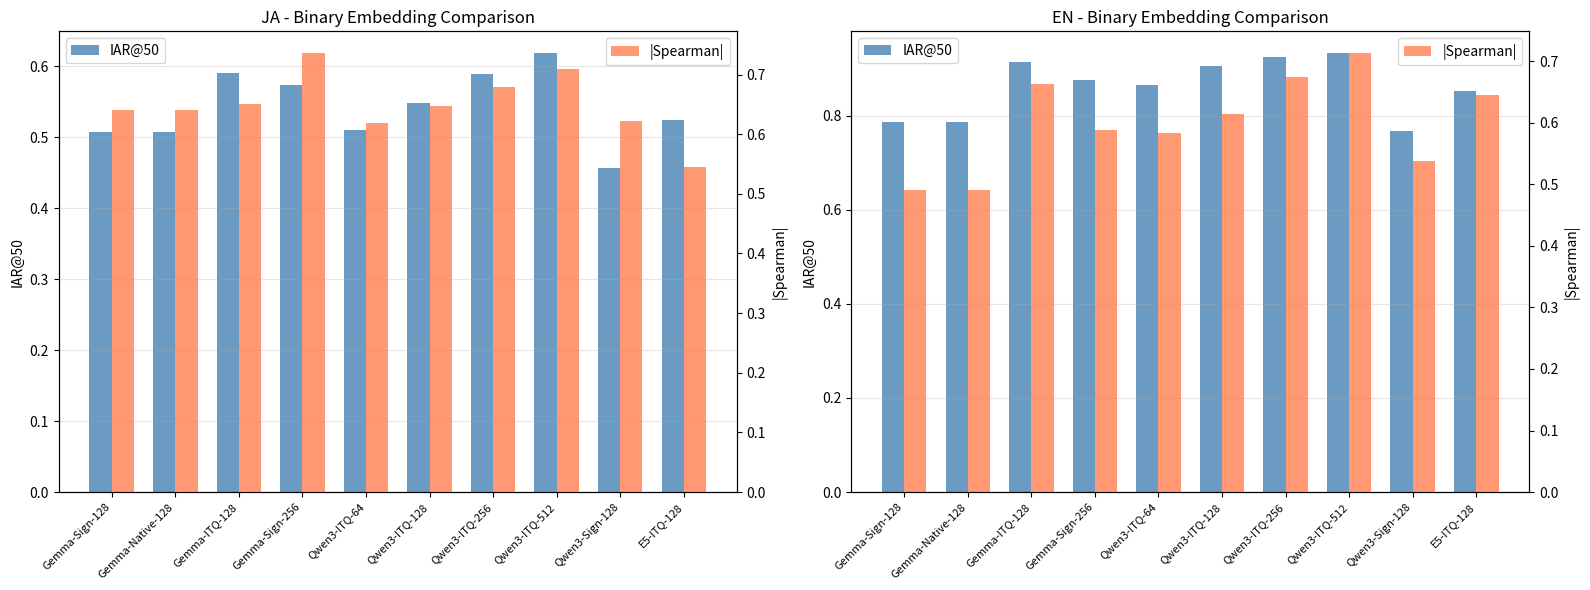

Saved: data/94_binary_vs_itq_comparison.png


In [11]:
# 可視化: IAR@50 比較
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, lang in enumerate(['ja', 'en']):
    lang_df = df_all[df_all['lang'] == lang].copy()
    
    # モデル+方式でグループ化
    labels = lang_df['label'].tolist()
    iar = lang_df['IAR@50'].values
    spear = lang_df['Spearman'].abs().values  # 絶対値
    
    x = np.arange(len(labels))
    width = 0.35
    
    ax1 = axes[ax_idx]
    bars1 = ax1.bar(x - width/2, iar, width, label='IAR@50', alpha=0.8, color='steelblue')
    ax1.set_ylabel('IAR@50')
    ax1.set_title(f'{lang.upper()} - Binary Embedding Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, spear, width, label='|Spearman|', alpha=0.8, color='coral')
    ax2.set_ylabel('|Spearman|')
    
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "94_binary_vs_itq_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/94_binary_vs_itq_comparison.png")

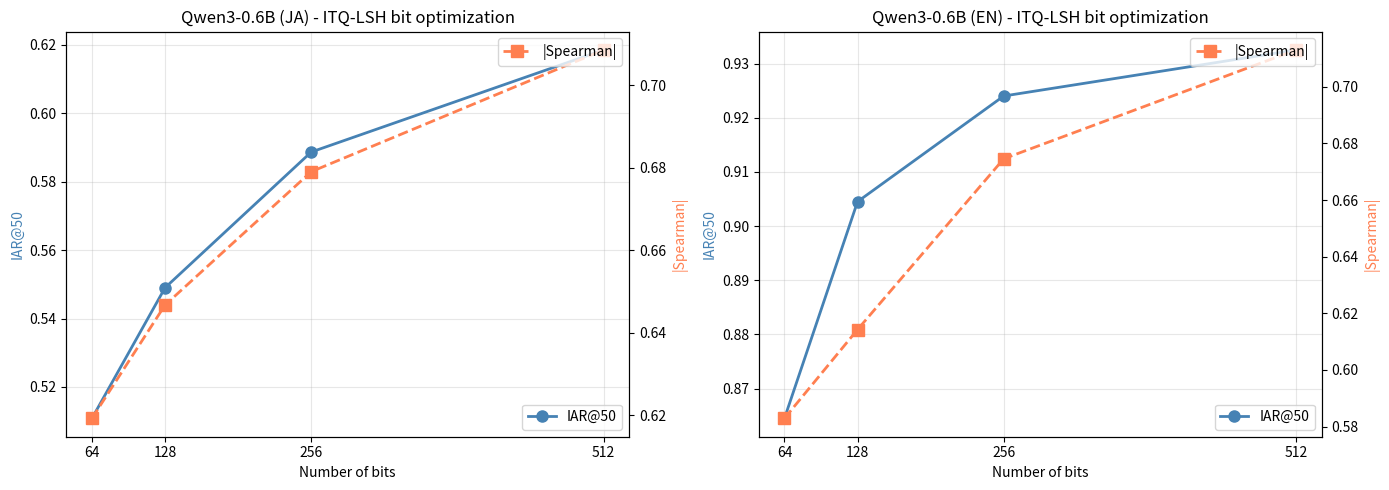

Saved: data/94_qwen3_bit_optimization.png


In [12]:
# Qwen3 ビット数 vs 性能のプロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, lang in enumerate(['ja', 'en']):
    qwen_lang = df_qwen[(df_qwen['lang'] == lang) & (df_qwen['method'].str.startswith('ITQ'))].copy()
    qwen_lang = qwen_lang.sort_values('n_bits')
    
    ax1 = axes[ax_idx]
    ax1.plot(qwen_lang['n_bits'], qwen_lang['IAR@50'], 'o-', color='steelblue', 
             label='IAR@50', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of bits')
    ax1.set_ylabel('IAR@50', color='steelblue')
    ax1.set_title(f'Qwen3-0.6B ({lang.upper()}) - ITQ-LSH bit optimization')
    ax1.set_xticks(qwen_lang['n_bits'])
    
    ax2 = ax1.twinx()
    ax2.plot(qwen_lang['n_bits'], qwen_lang['Spearman'].abs(), 's--', color='coral',
             label='|Spearman|', linewidth=2, markersize=8)
    ax2.set_ylabel('|Spearman|', color='coral')
    
    ax1.legend(loc='lower right')
    ax2.legend(loc='upper right')
    ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "94_qwen3_bit_optimization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/94_qwen3_bit_optimization.png")

## 8. まとめと考察

### 8.1 ネイティブバイナリ vs ITQ-LSH（Gemma-300M）

| 方式 | JA IAR@50 | EN IAR@50 | JA Spearman | EN Spearman |
|------|-----------|-----------|-------------|-------------|
| Sign/Native-128 | 0.508 | 0.786 | -0.641 | -0.491 |
| **ITQ-128** | **0.590** | **0.913** | **-0.651** | **-0.662** |
| Sign-256 | 0.574 | 0.876 | -0.736 | -0.589 |

- **ネイティブバイナリ（Sign）と`quantize_embeddings`の出力は完全に一致**（match rate=1.0）。Matryoshkaモデルの「バイナリEmbedding」は単なる符号バイナリ化であり、特別な学習は行われていない。
- **ITQ-LSHは同じ128bitでSign方式を大きく上回る**。特にEN（IAR@50: 0.786→0.913, +12.7pp）。ITQの回転最適化がPCA射影後の量子化誤差を低減する効果が明確。
- Sign-256（256bit）はITQ-128に近い性能だが、**ITQ-128はビット数半分で同等以上**の性能を達成。ストレージ効率でITQが優位。

### 8.2 Qwen3-0.6B ITQ-LSHビット数最適化

| ビット数 | JA IAR@50 | EN IAR@50 | JA Spearman | EN Spearman | PCA分散 |
|----------|-----------|-----------|-------------|-------------|---------|
| 64 | 0.511 | 0.865 | -0.619 | -0.583 | 53% |
| 128 | 0.549 | 0.905 | -0.647 | -0.614 | 70% |
| 256 | 0.589 | 0.924 | -0.679 | -0.675 | 86% |
| 512 | 0.619 | 0.933 | -0.709 | -0.713 | 97% |
| Sign-128 | 0.457 | 0.767 | -0.622 | -0.539 | — |

- **ビット数増加に伴い性能は単調に改善**するが、収穫逓減が明確。ENでは128→512bitで+2.8ppのみ。
- **ITQ-128 vs Sign-128**: IAR@50でJA +9.2pp、EN +13.8pp。ITQの回転最適化の効果はQwen3でも一貫して確認。
- **コスト・性能バランスでは128〜256bitが実用的**。512bitはストレージ4倍で性能向上はわずか。

### 8.3 モデル間比較（ITQ-128bit統一）

| モデル | JA IAR@50 | EN IAR@50 | JA Spearman | EN Spearman |
|--------|-----------|-----------|-------------|-------------|
| E5-base (768d) | 0.524 | 0.852 | -0.546 | -0.645 |
| Qwen3-0.6B (1024d) | 0.549 | 0.905 | -0.647 | -0.614 |
| Gemma-300M (768d) | 0.590 | 0.913 | -0.651 | -0.662 |

- **Gemma-300MがITQ-128bitで最高性能**。Matryoshka学習により先頭次元に情報が集中しており、PCA→ITQの射影と相性が良い。
- Qwen3はSpearmanではやや劣るがIAR@50ではE5を上回る。元次元が1024と大きく、128bitへの圧縮での情報損失が相対的に大きい。

### 8.4 結論

1. **ITQ-LSHはネイティブバイナリEmbeddingを一貫して上回る**。Matryoshkaモデルのバイナリ出力は単純なSign関数であり、ITQの回転最適化が量子化品質を明確に改善する。
2. **128bitが実用的なスイートスポット**。ストレージ効率と検索品質のバランスが最も良い。
3. **日本語タスクは英語より一貫して困難**（IAR@50が20〜35pp低い）。これはNB93でも観察された傾向で、日本語Wikipedia記事の段落間類似度構造の違いに起因する。
4. **Gemma-300M + ITQ-128の組み合わせが最も効率的**。300Mパラメータという軽量さで最高のバイナリ検索性能を達成。

### 参考: モデルサイズと推論速度の比較（NB91より）

| 項目 | E5-base | Gemma-300M | Qwen3-0.6B |
|------|---------|------------|------------|
| パラメータ数 | 278M | 308M | 600M |
| Embedding次元 | 768 | 768 | 1024 |
| JA推論速度 (docs/sec) | 413 | 201 | 61 |
| EN推論速度 (docs/sec) | 1077 | 523 | 170 |
| E5比の速度 (JA) | 1.0x | 0.49x | 0.15x |

- Gemma-300MはE5-baseとほぼ同規模（308M vs 278M）だが、Gemma2アーキテクチャのため**推論速度は約半分**。
- Qwen3-0.6BはパラメータがGemmaの約2倍で、**速度はE5の約1/7**。LLMベースのデコーダアーキテクチャが推論コストに影響。
- **品質と速度のトレードオフ**: Gemma-300Mはハッシュ品質最高かつモデルサイズも小さく、速度低下も許容範囲。Qwen3-0.6Bは品質面でGemmaに次ぐが速度面のコストが大きい。

## 9. 非公開データでの Gemma-300M 比較実験

### 目的
- Wikipedia で学習した ITQ-LSH の超平面を、**ドメインの異なる非公開データ**に適用した場合の性能を検証
- デフォルトの Sign-128bit とITQ-128bit の比較（汎化性能の確認）

### ITQ-LSH 学習データの確認
NB94 セクション4で使用した ITQ-LSH の学習データ:
- **データソース**: NB93 の Wikipedia パッセージ（`wikimedia/wikipedia 20231101`）
- **JA**: 500記事 → 2,389パッセージ（3〜5段落/記事、80〜500文字/段落）
- **EN**: 500記事 → 2,478パッセージ
- **ITQ設定**: n_bits=128, n_iterations=50, seed=42

参考: NB91 では Wikipedia 10,000文書/言語（先頭500文字）で ITQ を学習。
NB94 のほうがパッセージ単位のため、より細かい粒度のデータで学習している。

In [13]:
# ITQ-LSH 学習データの確認（NB94 セクション4と同じ条件で再学習）
print("=== ITQ-LSH 学習データの確認 ===")
print(f"JA Wikipedia embeddings: {emb_gemma_ja.shape}")
print(f"EN Wikipedia embeddings: {emb_gemma_en.shape}")
print(f"合計: {emb_gemma_ja.shape[0] + emb_gemma_en.shape[0]} パッセージ")
print(f"次元数: {emb_gemma_ja.shape[1]}")
print()

# JA/EN 混合で ITQ を学習（非公開データは JA/EN 混在のため）
emb_wiki_mixed = np.vstack([emb_gemma_ja, emb_gemma_en])
print(f"混合学習データ: {emb_wiki_mixed.shape}")

itq_wiki = ITQLSH(n_bits=128, n_iterations=50, seed=42)
itq_wiki.fit(emb_wiki_mixed)

# Wikipedia データでの Spearman を確認（ベースライン）
rng = np.random.default_rng(42)
n_wiki = len(emb_wiki_mixed)
idx1 = rng.choice(n_wiki, 10000, replace=True)
idx2 = rng.choice(n_wiki, 10000, replace=True)
mask = idx1 != idx2
idx1, idx2 = idx1[mask], idx2[mask]

cos_wiki = np.sum(emb_wiki_mixed[idx1] * emb_wiki_mixed[idx2], axis=1)

# Sign-128
sign_wiki = sign_binarize(emb_wiki_mixed, 128)
ham_sign_wiki = np.sum(sign_wiki[idx1] != sign_wiki[idx2], axis=1)
sp_sign_wiki, _ = spearmanr(ham_sign_wiki, cos_wiki)

# ITQ-128
itq_wiki_hashes = itq_wiki.transform(emb_wiki_mixed)
ham_itq_wiki = np.sum(itq_wiki_hashes[idx1] != itq_wiki_hashes[idx2], axis=1)
sp_itq_wiki, _ = spearmanr(ham_itq_wiki, cos_wiki)

print(f"\n=== Wikipedia ベースライン (JA+EN混合, {n_wiki}件) ===")
print(f"  Sign-128 Spearman: {sp_sign_wiki:.4f}")
print(f"  ITQ-128  Spearman: {sp_itq_wiki:.4f}")

=== ITQ-LSH 学習データの確認 ===
JA Wikipedia embeddings: (2389, 768)
EN Wikipedia embeddings: (2478, 768)
合計: 4867 パッセージ
次元数: 768

混合学習データ: (4867, 768)
ITQ学習開始: samples=4867, dim=768, bits=128
  Centering完了: mean_norm=0.2758
  PCA完了: explained_variance=62.20%
  ITQ iteration 10: quantization_error=0.8929
  ITQ iteration 20: quantization_error=0.8922
  ITQ iteration 30: quantization_error=0.8918
  ITQ iteration 40: quantization_error=0.8917
  ITQ iteration 50: quantization_error=0.8916
ITQ学習完了

=== Wikipedia ベースライン (JA+EN混合, 4867件) ===
  Sign-128 Spearman: -0.5482
  ITQ-128  Spearman: -0.6947


In [14]:
# 非公開データの読み込み
import duckdb

PRIVATE_DB = DATA_DIR / "resou_data.duckdb"  # 非公開DB
con = duckdb.connect(str(PRIVATE_DB), read_only=True)
private_df = con.execute("""
    SELECT id, title, combined_text, language
    FROM documents
    WHERE combined_text IS NOT NULL AND LENGTH(combined_text) > 0
    ORDER BY id
""").fetchdf()
con.close()

print(f"非公開データ: {len(private_df)} 件")
print(f"  JA: {(private_df['language'] == 'ja').sum()} 件")
print(f"  EN: {(private_df['language'] == 'en').sum()} 件")
print(f"  テキスト長: mean={private_df['combined_text'].str.len().mean():.0f}, "
      f"max={private_df['combined_text'].str.len().max()}")
print(f"\nサンプル (JA):")
ja_sample = private_df[private_df['language'] == 'ja'].iloc[0]
print(f"  title: {ja_sample['title']}")
print(f"  text: {ja_sample['combined_text'][:100]}...")
print(f"\nサンプル (EN):")
en_sample = private_df[private_df['language'] == 'en'].iloc[0]
print(f"  title: {en_sample['title']}")
print(f"  text: {en_sample['combined_text'][:100]}...")

非公開データ: 2789 件
  JA: 1614 件
  EN: 1175 件
  テキスト長: mean=517, max=2752

サンプル (JA):
  title: 「削らない治療」から「取り戻す歯科医療」まで―広がる歯学研究
  text: 「削らない治療」から「取り戻す歯科医療」まで―広がる歯学研究

「削らない治療」から「取り戻す歯科医療」まで―広がる歯学研究  ●削って・詰める虫歯治療はもう古い
●初期虫歯が自分で元に戻る仕組み
●...

サンプル (EN):
  title: An Investigation into the Human Resource Challenges Faced by Organizations
  text: An Investigation into the Human Resource Challenges Faced by Organizations

An Investigation into th...


In [15]:
# Gemma-300M で非公開データの Embedding を生成
from sentence_transformers import SentenceTransformer

GEMMA_MODEL_ID = "google/embeddinggemma-300m"
print(f"Loading {GEMMA_MODEL_ID}...")
model_gemma = SentenceTransformer(GEMMA_MODEL_ID, device="cuda")

texts_private = private_df['combined_text'].tolist()
print(f"Encoding {len(texts_private)} documents...")
emb_private = model_gemma.encode(
    texts_private, batch_size=64, normalize_embeddings=True, show_progress_bar=True
)
print(f"Embedding shape: {emb_private.shape}")

# 言語別に分割
ja_mask = (private_df['language'] == 'ja').values
en_mask = (private_df['language'] == 'en').values
emb_private_ja = emb_private[ja_mask]
emb_private_en = emb_private[en_mask]
print(f"  JA: {emb_private_ja.shape}")
print(f"  EN: {emb_private_en.shape}")

del model_gemma
clear_gpu()
print("Done.")

Loading google/embeddinggemma-300m...
Encoding 2789 documents...


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Embedding shape: (2789, 768)
  JA: (1614, 768)
  EN: (1175, 768)
Done.


In [16]:
# 非公開データに対して Sign-128 / ITQ-128 を適用して比較
private_results = []

for label, emb, lang in [
    ('全体 (JA+EN)', emb_private, 'mixed'),
    ('JA のみ', emb_private_ja, 'ja'),
    ('EN のみ', emb_private_en, 'en'),
]:
    n = len(emb)
    rng = np.random.default_rng(42)
    idx1 = rng.choice(n, min(10000, n * 5), replace=True)
    idx2 = rng.choice(n, min(10000, n * 5), replace=True)
    m = idx1 != idx2
    idx1, idx2 = idx1[m], idx2[m]

    cos_sims = np.sum(emb[idx1] * emb[idx2], axis=1)

    # Sign-128
    sign_h = sign_binarize(emb, 128)
    ham_sign = np.sum(sign_h[idx1] != sign_h[idx2], axis=1)
    sp_sign, _ = spearmanr(ham_sign, cos_sims)

    # ITQ-128（Wikipedia 学習済み超平面を適用）
    itq_h = itq_wiki.transform(emb)
    ham_itq = np.sum(itq_h[idx1] != itq_h[idx2], axis=1)
    sp_itq, _ = spearmanr(ham_itq, cos_sims)

    # Top-K 近傍の一致率（cosine top-K vs Hamming top-K）
    K = 10
    n_queries = min(500, n)
    query_ids = rng.choice(n, n_queries, replace=False)
    overlap_sign_list = []
    overlap_itq_list = []
    for qid in query_ids:
        # cosine での top-K
        cos_dists = 1 - emb[qid] @ emb.T
        cos_dists[qid] = 999
        topK_cos = set(np.argsort(cos_dists)[:K])

        # Sign での top-K
        h_sign = np.sum(sign_h[qid] != sign_h, axis=1)
        h_sign[qid] = 999
        topK_sign = set(np.argsort(h_sign)[:K])
        overlap_sign_list.append(len(topK_cos & topK_sign) / K)

        # ITQ での top-K
        h_itq = np.sum(itq_h[qid] != itq_h, axis=1)
        h_itq[qid] = 999
        topK_itq = set(np.argsort(h_itq)[:K])
        overlap_itq_list.append(len(topK_cos & topK_itq) / K)

    overlap_sign = np.mean(overlap_sign_list)
    overlap_itq = np.mean(overlap_itq_list)

    result = {
        'データ': label,
        'N': n,
        'Sign-128 Spearman': sp_sign,
        'ITQ-128 Spearman': sp_itq,
        f'Sign Top-{K} overlap': overlap_sign,
        f'ITQ Top-{K} overlap': overlap_itq,
    }
    private_results.append(result)

    print(f"\n{'='*60}")
    print(f"{label} (N={n})")
    print(f"{'='*60}")
    print(f"  Spearman:    Sign={sp_sign:.4f}  ITQ={sp_itq:.4f}  (差: {sp_itq - sp_sign:+.4f})")
    print(f"  Top-{K} overlap: Sign={overlap_sign:.4f}  ITQ={overlap_itq:.4f}  (差: {overlap_itq - overlap_sign:+.4f})")

print("\n--- 非公開データ サマリー ---")
df_private = pd.DataFrame(private_results)
print(df_private.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


全体 (JA+EN) (N=2789)
  Spearman:    Sign=-0.6333  ITQ=-0.7638  (差: -0.1304)
  Top-10 overlap: Sign=0.3082  ITQ=0.3230  (差: +0.0148)

JA のみ (N=1614)
  Spearman:    Sign=-0.6188  ITQ=-0.7712  (差: -0.1523)
  Top-10 overlap: Sign=0.3164  ITQ=0.3454  (差: +0.0290)

EN のみ (N=1175)
  Spearman:    Sign=-0.5813  ITQ=-0.7007  (差: -0.1194)
  Top-10 overlap: Sign=0.2898  ITQ=0.3186  (差: +0.0288)

--- 非公開データ サマリー ---
       データ    N  Sign-128 Spearman  ITQ-128 Spearman  Sign Top-10 overlap  ITQ Top-10 overlap
全体 (JA+EN) 2789            -0.6333           -0.7638               0.3082              0.3230
     JA のみ 1614            -0.6188           -0.7712               0.3164              0.3454
     EN のみ 1175            -0.5813           -0.7007               0.2898              0.3186


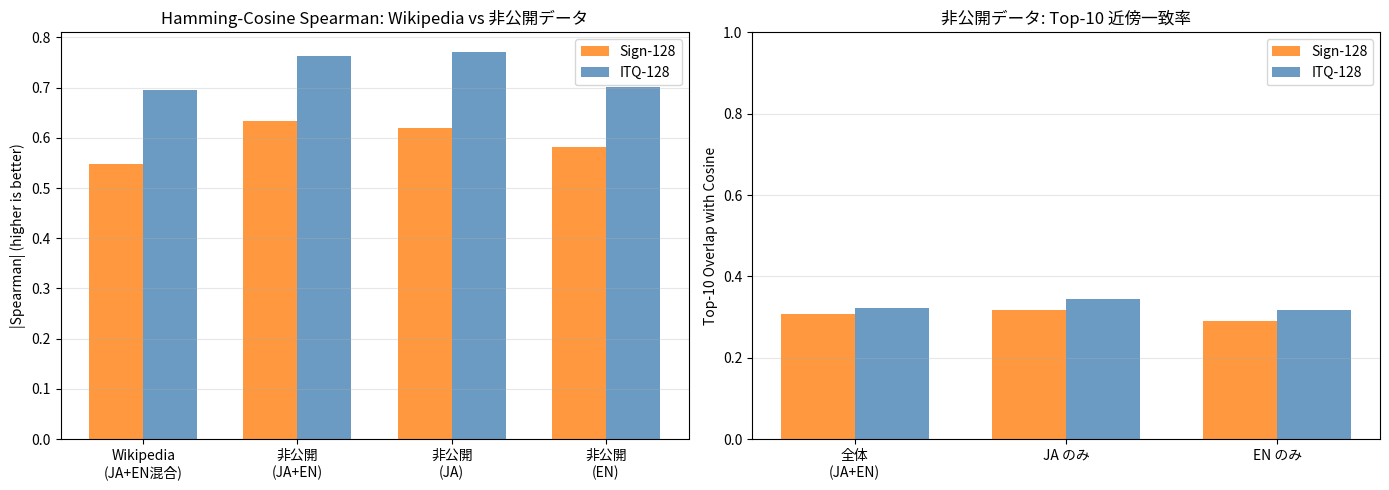

Saved: data/94_private_sign_vs_itq.png


In [17]:
# Wikipedia vs 非公開データの比較可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: Spearman 比較
categories = ['Wikipedia\n(JA+EN混合)', '非公開\n(JA+EN)', '非公開\n(JA)', '非公開\n(EN)']
sign_spear = [sp_sign_wiki] + [r['Sign-128 Spearman'] for r in private_results]
itq_spear = [sp_itq_wiki] + [r['ITQ-128 Spearman'] for r in private_results]

x = np.arange(len(categories))
width = 0.35
bars1 = axes[0].bar(x - width/2, [-s for s in sign_spear], width,
                     label='Sign-128', alpha=0.8, color='tab:orange')
bars2 = axes[0].bar(x + width/2, [-s for s in itq_spear], width,
                     label='ITQ-128', alpha=0.8, color='steelblue')
axes[0].set_ylabel('|Spearman| (higher is better)')
axes[0].set_title('Hamming-Cosine Spearman: Wikipedia vs 非公開データ')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 右: Top-K overlap 比較
categories_private = ['全体\n(JA+EN)', 'JA のみ', 'EN のみ']
sign_overlap = [r['Sign Top-10 overlap'] for r in private_results]
itq_overlap = [r['ITQ Top-10 overlap'] for r in private_results]

x2 = np.arange(len(categories_private))
bars3 = axes[1].bar(x2 - width/2, sign_overlap, width,
                     label='Sign-128', alpha=0.8, color='tab:orange')
bars4 = axes[1].bar(x2 + width/2, itq_overlap, width,
                     label='ITQ-128', alpha=0.8, color='steelblue')
axes[1].set_ylabel('Top-10 Overlap with Cosine')
axes[1].set_title('非公開データ: Top-10 近傍一致率')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories_private)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(DATA_DIR / "94_private_sign_vs_itq.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/94_private_sign_vs_itq.png")

### 9.1 非公開データ実験のまとめ

**ITQ-LSH 学習データ**:
- Wikipedia パッセージ JA 2,389件 + EN 2,478件 = 計 4,867件（NB93由来）
- `wikimedia/wikipedia 20231101` から500記事/言語、3〜5段落/記事を抽出
- Gemma-300M（768次元）で Embedding 化後に ITQ 学習（128bit, 50 iterations）

**非公開データ**:
- 大学の研究紹介テキスト 2,789件（JA 1,614件 + EN 1,175件）
- Wikipedia とはドメインが異なる

#### Spearman 相関の比較

| データ | Sign-128 | ITQ-128 | ITQ改善幅 |
|--------|----------|---------|----------|
| Wikipedia (JA+EN混合) | -0.548 | -0.695 | +0.147 |
| 非公開 全体 (JA+EN) | -0.633 | **-0.764** | **+0.130** |
| 非公開 JA のみ | -0.619 | **-0.771** | **+0.152** |
| 非公開 EN のみ | -0.581 | **-0.701** | **+0.119** |

- **ITQ-LSH は非公開データでも Sign-128 を大幅に上回る**。Spearman の改善幅は +0.12〜0.15 で、Wikipedia 上のベースライン（+0.15）とほぼ同等。
- **非公開データでの |Spearman| が Wikipedia より高い**（Sign: 0.63 vs 0.55, ITQ: 0.76 vs 0.69）。研究紹介テキストは Wikipedia より類似度構造がはっきりしており、ハッシュでの順序保存がしやすい。
- **JA が EN より ITQ の改善幅が大きい**（+0.152 vs +0.119）。

#### Top-10 近傍一致率

| データ | Sign-128 | ITQ-128 | 差 |
|--------|----------|---------|-----|
| 全体 (JA+EN) | 0.308 | 0.323 | +0.015 |
| JA のみ | 0.316 | 0.345 | +0.029 |
| EN のみ | 0.290 | 0.319 | +0.029 |

- Top-10 overlap は両方式とも **0.29〜0.35 と低い**。128bit Hamming 距離での Top-10 と cosine での Top-10 は 3割程度しか一致しない。
- ITQ の改善は +1.5〜2.9pp と控えめ。Spearman（全体の順序相関）では大きく改善するが、**Top-K の精密な一致**にはより多くのビット数やリランキングが必要。

#### 結論

1. **Wikipedia で学習した ITQ-LSH の超平面はドメイン外の非公開データでも有効に汎化する**。Spearman 改善幅が Wikipedia 上とほぼ同等であり、ITQ の回転行列はモデルの Embedding 空間の構造を捉えており、データ分布の変化に頑健。
2. **Spearman（順序保存）は大幅に改善されるが、Top-10 overlap は低水準**。これは 128bit という限られたビット数で 2,789件の中から上位10件を正確に特定するのが本質的に難しいことを意味する。実用的にはリランキング（Hamming で候補絞り → cosine で精密順位付け）が必須。
3. **ITQ の学習データに非公開データを含める必要はない**。Wikipedia のみで十分な汎化性能が得られる。